In [1]:
%cd /Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code

%pwd


/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code


'/Users/yoavfreund/projects/VoltageDimentionalReduction/clean_code'

In [2]:


import numpy as np
from typing import Union, Optional, List, Any, Tuple, Callable, Dict
from itertools import product
import pandas
import matplotlib.pyplot as plt

from scipy.sparse.linalg import cg
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.datasets import fetch_openml


import landmark
import voltagemap
import problem
import solver
import visualization
import setofpoints
import kmeans
from Utilities import config



In [ ]:

workspace_file="../../Voltage_Temp/Intermediates/workspace.pkl"
!ls $workspace_file
import dill
dill.load_session(workspace_file)


../../Voltage_Temp/Intermediates/workspace.pkl


In [18]:
voltages.shape

(1000,)

In [ ]:
this_landmark=landmark.Landmark(index,1.0)
voltages=solver.compute_voltages(
plt.hist(voltages.flatten(), bins=100);

AttributeError: 'Solver' object has no attribute 'flatten'

In [21]:
def f(x):
    return f"{x:5.3f}"

In [24]:
del solver

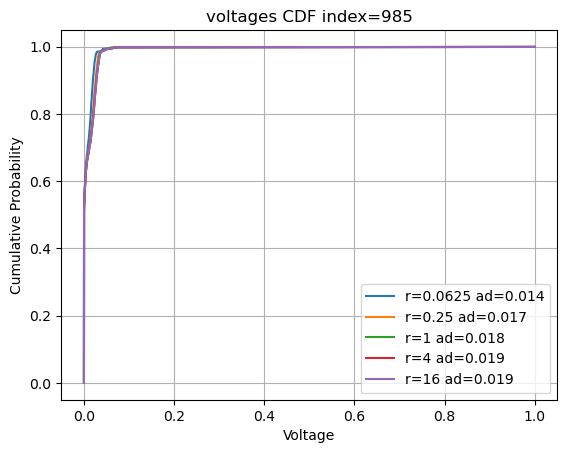

In [135]:
import random
index=random.randint(0, len(point_set))
#index=772 # thin
#index=221,638,363 # fat
#index=772
this_landmark=landmark.Landmark(index,1.0)

debug=False

import solver
from problem import Problem
for i in range(-4,6,2):
    r= 2**i
    _problem=Problem(point_set,r=r)
    volt_solver = solver.Solver(_problem)
    voltages = volt_solver.compute_voltages(this_landmark)
    #plt.hist(voltages.flatten(), bins=100);
    #plot cumulative distribution
    
    
    sorted = np.sort(voltages.flatten())
    low=500
    if debug:
        scaled=sorted
    else:
        scaled = (sorted - sorted[low] )/ (sorted[-1] - sorted[low])
        scaled=np.maximum(scaled,0)
    P=np.arange(0,1.00,(1.0/scaled.shape[0]))
    if P.shape[0]>len(scaled):
        P=P[0:len(scaled)]

    advantage=np.mean(scaled[low:])
    plt.plot(scaled,P,label=f"r={r} ad={f(advantage)}")
plt.legend(loc='lower right')
plt.ylabel("Cumulative Probability")
plt.xlabel("Voltage")
plt.title(f"voltages CDF index={index}")
plt.grid()

Elbow point at index 879, voltage 0.04500808300234437, probability 0.879


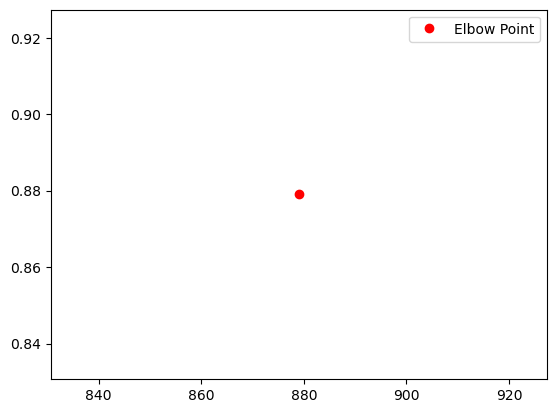

In [63]:
#write code that finds the elbow point in the voltage vs cummulative probability curve
# using the max distance frm the diagonal line method
def find_elbow_point(sorted,P):
    max_distance = 0
    elbow_point = 0
    for i in range(len(sorted)):
        distance = np.abs(P[i] - sorted[i])
        if distance > max_distance:
            max_distance = distance
            elbow_point = i
    return elbow_point, sorted[elbow_point], P[elbow_point]
elbow_point, elbow_voltage, elbow_probability = find_elbow_point(scaled, P)
print(f"Elbow point at index {elbow_point}, voltage {elbow_voltage}, probability {elbow_probability}")
plt.plot(elbow_point, elbow_probability, 'ro', label='Elbow Point')
plt.legend()
plt.show()
